In [1]:
import matplotlib.pyplot as plt
from elfdannagalac.dmspectrum import dmspectra
import numpy as np

# Electron spectrum from DM annihilation
## Spectrum using cosmiXs

I will start by defining some values for parameters. I consider annihilation to $W$ bosons. The mass of the candidate is 10 TeV. The energy range is set to [$10^{-5},m_\chi$]. Firs, I select the project `cosmiXs`, but at the end, I show the comparison between `cosmiXs` and `pppc4dmid` projects

In [2]:
mass    = 1.e+4
emin    = 1.e-5
emax    = mass
channel = 'W'

cosmix_spec = dmspectra.dmspectrum(mass,emin,emax,channel)

Min energy is below the allowed value
Setting to the min value 1.109e-05


Here, I show how to get information about the different parameters of the spectrum class. To change the values, you can use the following syntax:

```
cosmix_spec.mass = mass_value # In GeV
```

In [3]:
# Checking all the properties
cosmix_spec.mass

10000.0

In [4]:
cosmix_spec.channel

'W'

In [5]:
cosmix_spec.emin

1.109174815262401e-05

In [6]:
cosmix_spec.emax

10000.0

In [7]:
cosmix_spec.process

'anna'

In [8]:
cosmix_spec.dataproject

'cosmixs'

## Get the spectrum
To get the e-spectrum, then I simply call the method `spectrum`. Easy, peasy c:, right?

In [9]:
e_spectra = cosmix_spec.spectrum()

## Spectrum for PPPC4-DMID
The only property that is unmutable in the class, is the project used to compute the spectrum. So, if you want to compute the spectrum for the project `pppc4dmid`, you need to define a new instance of the class.

In [10]:
pppc4dmid_spec = dmspectra.dmspectrum(mass,emin,emax,channel,project='pppc4dmid')

Min energy is below the allowed value
Setting to the min value 1.259e-05


In [11]:
e_pppc4dmid = pppc4dmid_spec.spectrum()

## Plotting

Then, I can compare the e-spectrum from the two projects. If you are interested about the differences between both spectra, you can check the original references.

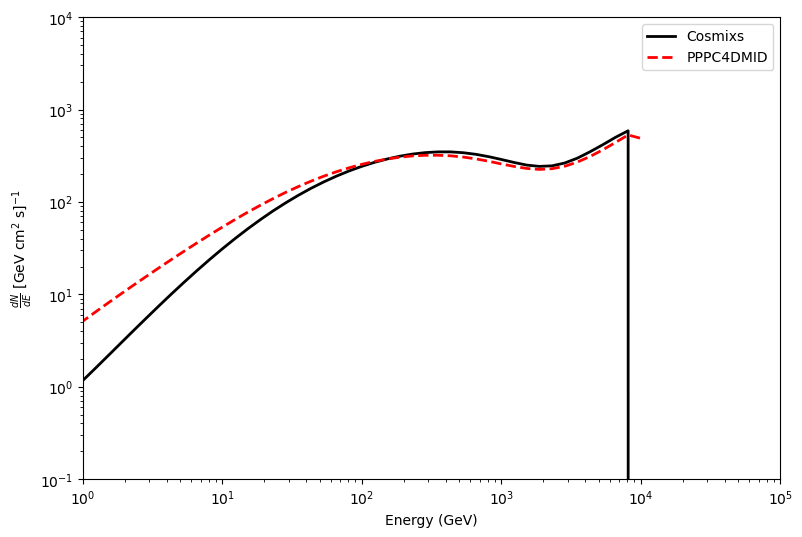

In [20]:
fig,ax = plt.subplots(figsize=(9,6))

ax.plot(cosmix_spec.engs,cosmix_spec.engs**2*e_spectra,lw=2,color='black',label='Cosmixs')
ax.plot(pppc4dmid_spec.engs,pppc4dmid_spec.engs**2*e_pppc4dmid,lw=2,color='red',ls='--',label='PPPC4DMID')
ax.set_xlabel('Energy (GeV)')
ax.set_ylabel(r'$\frac{dN}{dE}$ [GeV cm$^2$ s]$^{-1}$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1.0,1.e+5)
ax.set_ylim(1.e-1,1.e+4)
ax.legend()

# Electrom spectrum from DM decay

Now, I wil show how to compute the e-spectrum from decay of DM particles. The only difference is that the maximum energy will be set to 4 TeV.

In [13]:
emax = 4e+3
cosmiXsdecay   = dmspectra.dmspectrum(mass,emin,emax,channel,process='decay')
decay_spectrum = cosmiXsdecay.spectrum()

Min energy is below the allowed value
Setting to the min value 1.109e-05


And now, plotting

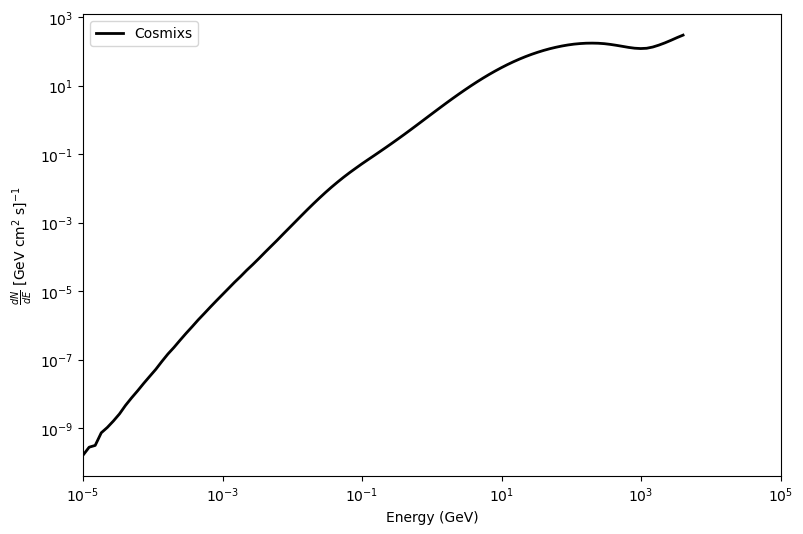

In [16]:
fig,ax = plt.subplots(figsize=(9,6))

ax.plot(cosmiXsdecay.engs,cosmiXsdecay.engs**2*decay_spectrum,lw=2,color='black',label='Cosmixs')
ax.set_xlabel('Energy (GeV)')
ax.set_ylabel(r'$\frac{dN}{dE}$ [GeV cm$^2$ s]$^{-1}$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(emin,1.e+5)
ax.legend()

We can compare also, between decay and annihilation:

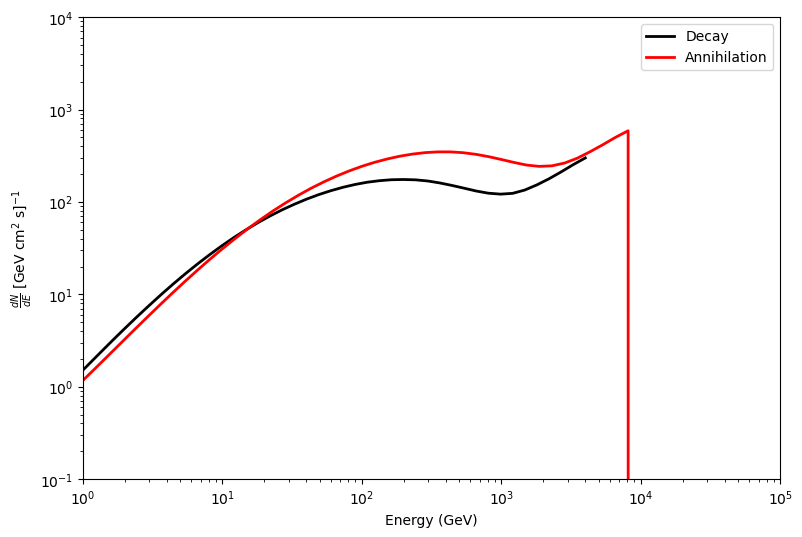

In [19]:
fig,ax = plt.subplots(figsize=(9,6))

ax.plot(cosmiXsdecay.engs,cosmiXsdecay.engs**2*decay_spectrum,lw=2,color='black',label='Decay')
ax.plot(cosmix_spec.engs,cosmix_spec.engs**2*e_spectra,lw=2,color='red',label='Annihilation')
ax.set_xlabel('Energy (GeV)')
ax.set_ylabel(r'$\frac{dN}{dE}$ [GeV cm$^2$ s]$^{-1}$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1.0,1.e+5)
ax.set_ylim(1.e-1,1.e+4)
ax.legend()